# Task 4: Predicting Insurance Claim Amounts

## Objective
Estimate the medical insurance claim amount based on personal data
such as age, BMI, smoking status, and region using Linear Regression.

## Dataset
Medical Cost Personal Dataset — contains 1338 records with features
like age, sex, BMI, children, smoker status, region, and charges.

In [15]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [16]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
# Check data types and missing values
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


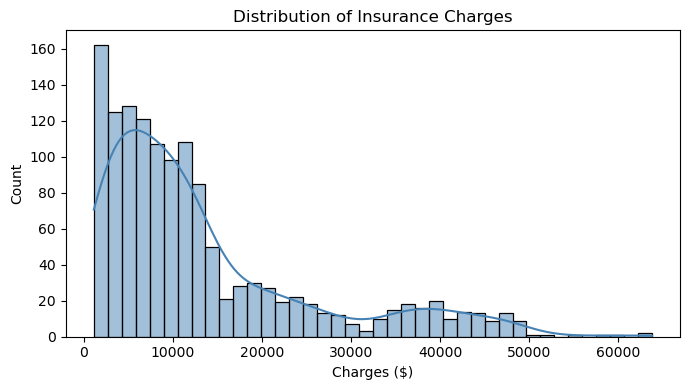

In [18]:
# Plot 1: Distribution of Insurance Charges
plt.figure(figsize=(7, 4))
sns.histplot(df['charges'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.tight_layout()
plt.savefig('charges_distribution.png')
plt.show()

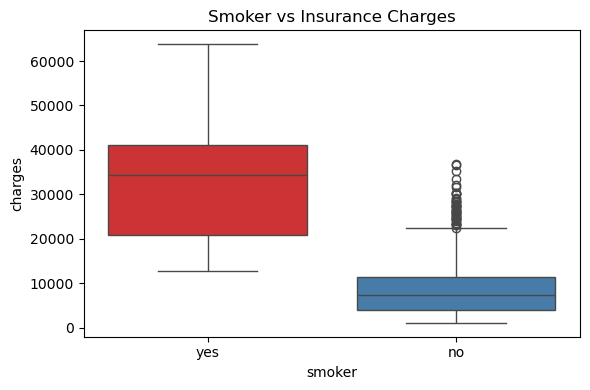

In [19]:
# Plot 2: Smoker vs Charges
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')
plt.title('Smoker vs Insurance Charges')
plt.tight_layout()
plt.savefig('smoker_vs_charges.png')
plt.show()

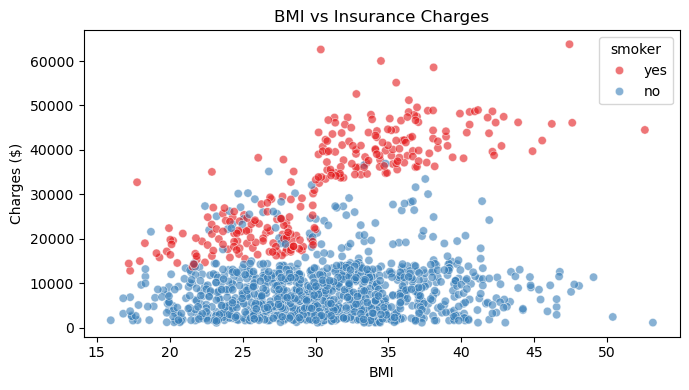

In [20]:
# Plot 3: BMI vs Charges
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.6)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.savefig('bmi_vs_charges.png')
plt.show()

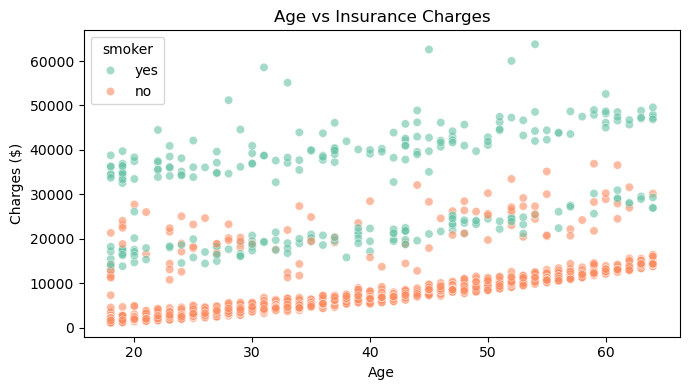

In [21]:
# Plot 4: Age vs Charges
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set2', alpha=0.6)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.savefig('age_vs_charges.png')
plt.show()

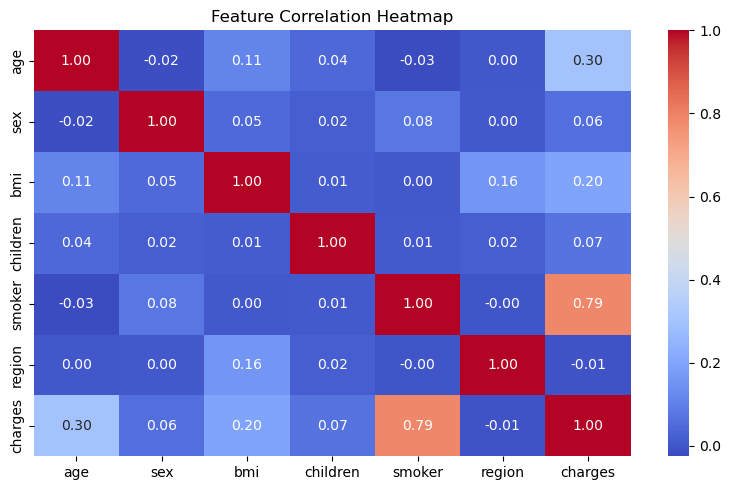

In [22]:
# Encode categorical columns temporarily for correlation
df_corr = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_corr[col] = le.fit_transform(df_corr[col])

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [23]:
# Encode categorical features
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['smoker'] = LabelEncoder().fit_transform(df['smoker'])

# One-Hot Encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("Encoding done! Sample data:")
df.head()

Encoding done! Sample data:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [24]:
# Define features (X) and target (y)
X = df.drop(columns=['charges'])
y = df['charges']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1070, 8)
Testing set size: (268, 8)


In [25]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

print("Model trained successfully!")
print("\nSample Predictions vs Actual:")
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(2)})
print(comparison)

Model trained successfully!

Sample Predictions vs Actual:
        Actual  Predicted
0   9095.06825    8969.55
1   5272.17580    7068.75
2  29330.98315   36858.41
3   9301.89355    9454.68
4  33750.29180   26973.17
5   4536.25900   10864.11
6   2117.33885     170.28
7  14210.53595   16903.45
8   3732.62510    1092.43
9  10264.44210   11218.34


In [26]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"Mean Absolute Error  (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

=== Model Evaluation ===
Mean Absolute Error  (MAE):  $4,181.19
Root Mean Squared Error (RMSE): $5,796.28
R² Score: 0.7836


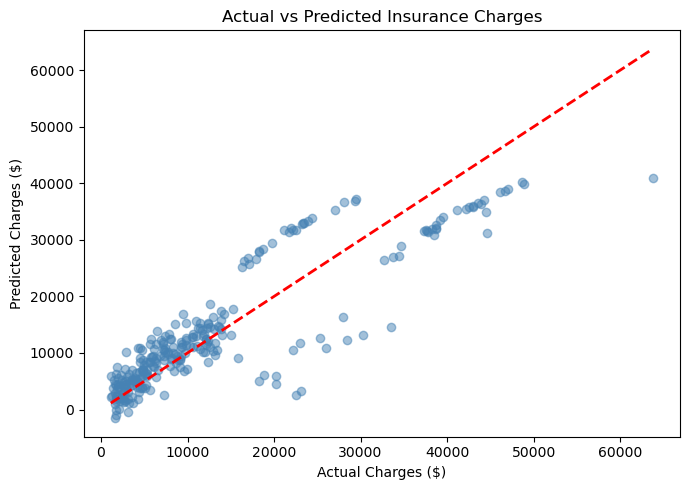

In [27]:
# Plot Actual vs Predicted charges
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

## Conclusion

- The dataset has **1338 rows** and **7 columns** with **no missing values**.
- **Smoking status** is the strongest predictor of insurance charges — smokers pay significantly more.
- **Age** and **BMI** also positively correlate with higher charges.
- The Linear Regression model achieved a good R² score showing reasonable predictive power.
- MAE and RMSE indicate the average dollar error in predictions.
- Future improvement: Try Ridge Regression or Random Forest for better accuracy.